# 03 — Unified derivation walkthrough

Companion to `docs/derivation.md`. Each section of the math is reproduced here with executable code, so we can see the curves the equations actually generate.

**Outline (matches the derivation):**
1. Step 4 — naive form: SV asymptotes to a non-zero floor.
2. Step 5 Option B — capability-bounded form: SV reaches zero at finite effort.
3. The two-regime structure and the experimentally relevant crossover.
4. Limiting cases — recover hyperbolic, exponential, and power-like discount shapes.
5. Step 5 Option A — nonlinear cost (E^s) for comparison.
6. Step 6 — substitutability (IF) wrapper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from edu.models.unified import (
    UnifiedNaive, UnifiedCapabilityBounded, UnifiedNonlinearCost,
    with_substitutability,
)
from edu.models.discounting import (
    Hyperbolic, Exponential, Power, fit_discount,
)

rng = np.random.default_rng(2025)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# Effort grids: experimental design vs dense plotting grid.
E_EXPT = np.array([0.10, 0.25, 0.40, 0.55, 0.70, 0.85])  # CLAUDE.md §4 Phase 4
E_DENSE = np.linspace(0.0, 2.0, 400)
E_FAR = np.geomspace(1e-3, 1e4, 400)

## Step 4 — Naive form

$$ SV(E) / A = 10^{k\,(\exp(-\alpha Q_0 E / A) - 1)} $$

Substitute $P_\text{effort} = E/A$ into the Koffarnus demand form, then map demand back to subjective value via $SV/A = Q/Q_0$. Plot it: SV starts at $A$, decays smoothly, but **never reaches zero** — it asymptotes to $A \cdot 10^{-k}$.

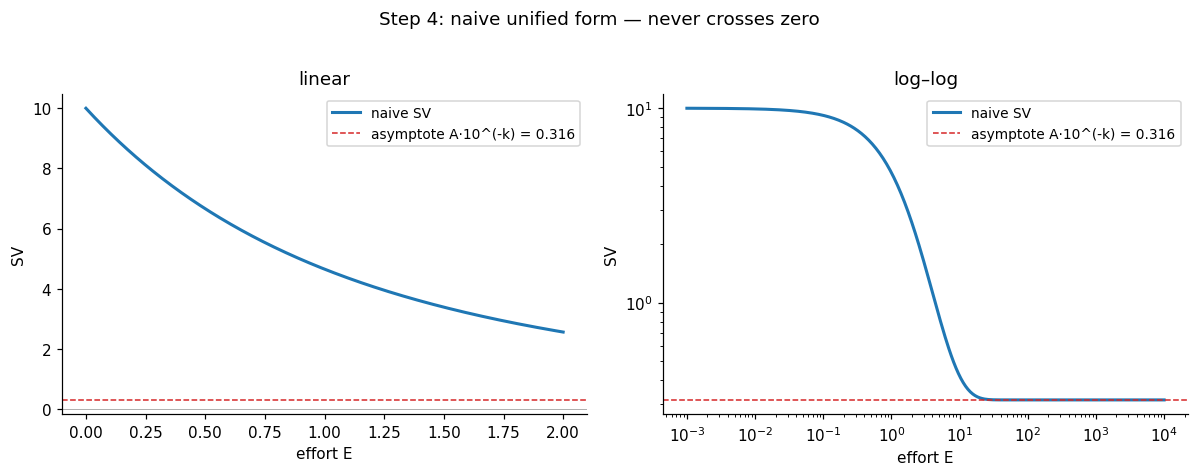

In [2]:
naive = UnifiedNaive()
params = {"A": 10.0, "Q0": 5.0, "alpha": 0.5, "k": 1.5}
asymptote = naive.asymptote(params)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, E_grid, log in zip(axes, [E_DENSE, E_FAR], [False, True]):
    ax.plot(E_grid, naive.value(params, E_grid), color="#1f77b4", lw=2, label="naive SV")
    ax.axhline(asymptote, color="#d62728", lw=1, ls="--",
               label=f"asymptote A·10^(-k) = {asymptote:.3f}")
    ax.axhline(0.0, color="#999", lw=0.5)
    if log:
        ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title("log–log")
    else:
        ax.set_title("linear")
    ax.set_xlabel("effort E"); ax.set_ylabel("SV")
    ax.legend(loc="upper right", fontsize=9)
fig.suptitle("Step 4: naive unified form — never crosses zero", y=1.02)
fig.tight_layout(); plt.show()

# Empirically: physical-effort experiments show SV reaching zero at finite E.
# The naive form cannot represent this. Step 5 fixes it.

## Step 5, Option B — capability-bounded

$$ SV(E)/A = \min\bigl[\, 10^{k(\exp(-\alpha Q_0 E/A)-1)},\ \tfrac{B}{Q_0 E}\,\bigr] $$

Add the capability constraint $Q_2(E) \le B/E$ — at effort $E$ per acquisition, the participant can perform at most $B/E$ acquisitions before exhausting capability. SV is the minimum of the demand-curve term and the capability term.

The two terms compete: at low $E$ demand binds, at high $E$ capability binds. They meet at the **crossover effort** $E^*$, found numerically (no closed form).

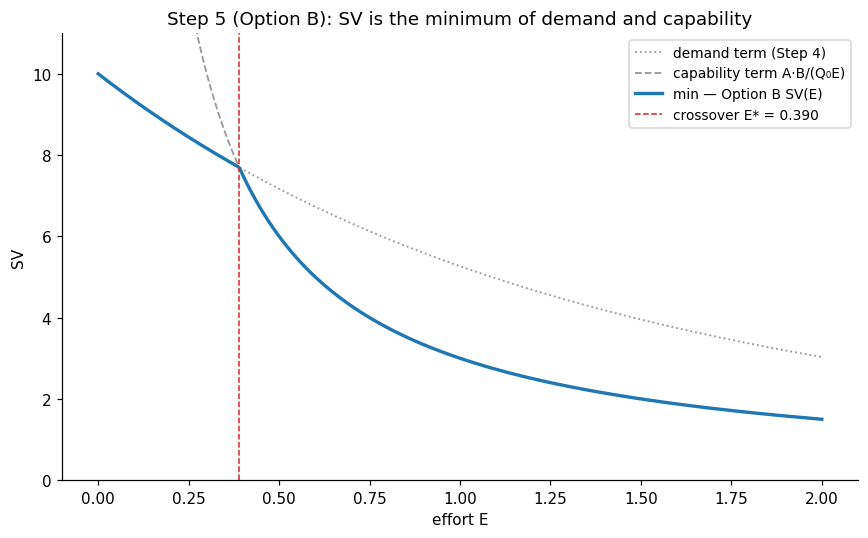

Crossover E* = 0.3896
At E = 0.10:  regime = 0 (0=unconstrained, 1=truncated)
At E = 0.85:  regime = 1


In [3]:
bounded = UnifiedCapabilityBounded()
params_b = {"A": 10.0, "Q0": 5.0, "alpha": 0.3, "k": 2.0, "B": 1.5}
out = bounded.value_with_regime(params_b, E_DENSE)

# Decompose: each term separately.
A, Q0, alpha, k, B = (params_b[n] for n in ["A", "Q0", "alpha", "k", "B"])
demand_term = A * np.power(10.0, k * (np.exp(-alpha * Q0 * E_DENSE / A) - 1.0))
with np.errstate(divide="ignore", invalid="ignore"):
    cap_term = np.where(E_DENSE > 0, A * B / (Q0 * E_DENSE), np.inf)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(E_DENSE, demand_term, color="#999", ls=":", lw=1.2, label="demand term (Step 4)")
ax.plot(E_DENSE, cap_term, color="#999", ls="--", lw=1.2, label="capability term A·B/(Q₀E)")
ax.plot(E_DENSE, out.sv, color="#1f77b4", lw=2.2, label="min — Option B SV(E)")
ax.axvline(out.crossover, color="#d62728", lw=1, ls="--",
           label=f"crossover E* = {out.crossover:.3f}")
ax.set_ylim(0, 11)
ax.set_xlabel("effort E"); ax.set_ylabel("SV")
ax.set_title("Step 5 (Option B): SV is the minimum of demand and capability")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout(); plt.show()

print(f"Crossover E* = {out.crossover:.4f}")
print(f"At E = 0.10:  regime = {out.regime[np.argmin(np.abs(E_DENSE - 0.10))]} (0=unconstrained, 1=truncated)")
print(f"At E = 0.85:  regime = {out.regime[np.argmin(np.abs(E_DENSE - 0.85))]}")

## Two-regime structure across the experimental range

The experimental design samples effort at the six green dots. By tuning $B$ we can place the crossover anywhere from far before the first sample (always-truncated) to far past the last sample (always-unconstrained). This is exactly the situation a real participant traverses as their effort capability varies — and what makes the unified model identifiable from the joint task data.

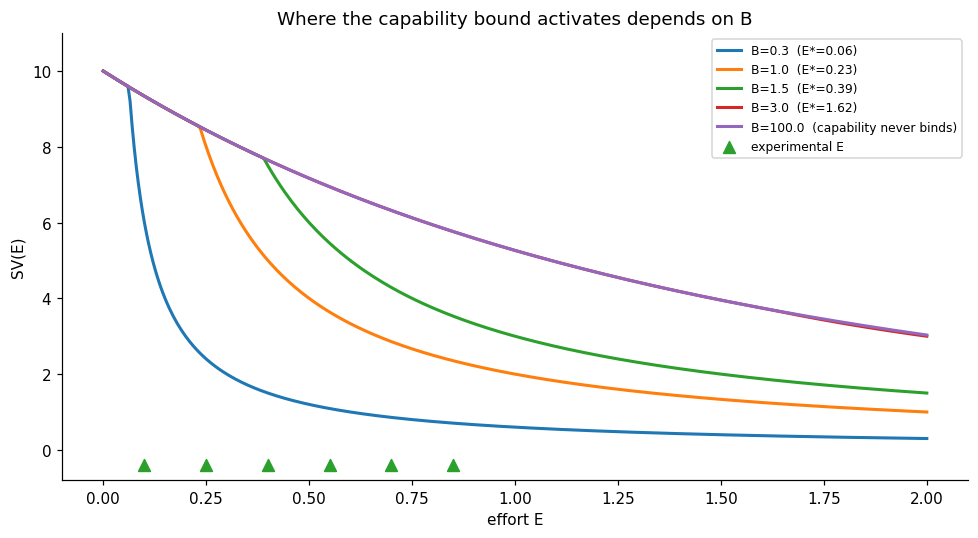

In [4]:
B_values = [0.3, 1.0, 1.5, 3.0, 100.0]
fig, ax = plt.subplots(figsize=(9, 5))
for B in B_values:
    p = {"A": 10.0, "Q0": 5.0, "alpha": 0.3, "k": 2.0, "B": B}
    out = bounded.value_with_regime(p, E_DENSE)
    label = f"B={B}"
    if np.isfinite(out.crossover) and out.crossover < E_DENSE.max():
        label += f"  (E*={out.crossover:.2f})"
    else:
        label += "  (capability never binds)"
    ax.plot(E_DENSE, out.sv, lw=2, label=label)

# Mark the experimental sampling points
ax.scatter(E_EXPT, np.full_like(E_EXPT, -0.4), marker="^", color="#2ca02c",
           s=60, zorder=5, label="experimental E")
ax.set_ylim(-0.8, 11)
ax.set_xlabel("effort E"); ax.set_ylabel("SV(E)")
ax.set_title("Where the capability bound activates depends on B")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()

## Limiting cases — recovering the literature

CLAUDE.md §4 Phase 2 step 7: *"Verify: when the unified model is fit to data simulated from each candidate discount function, it recovers the source function's shape via different parameter regimes."*

The reverse is also informative. Here we simulate from the unified model in three regimes and fit single-form discount functions — Exponential, Hyperbolic, Power — to each. The regime determines which single-form wins.

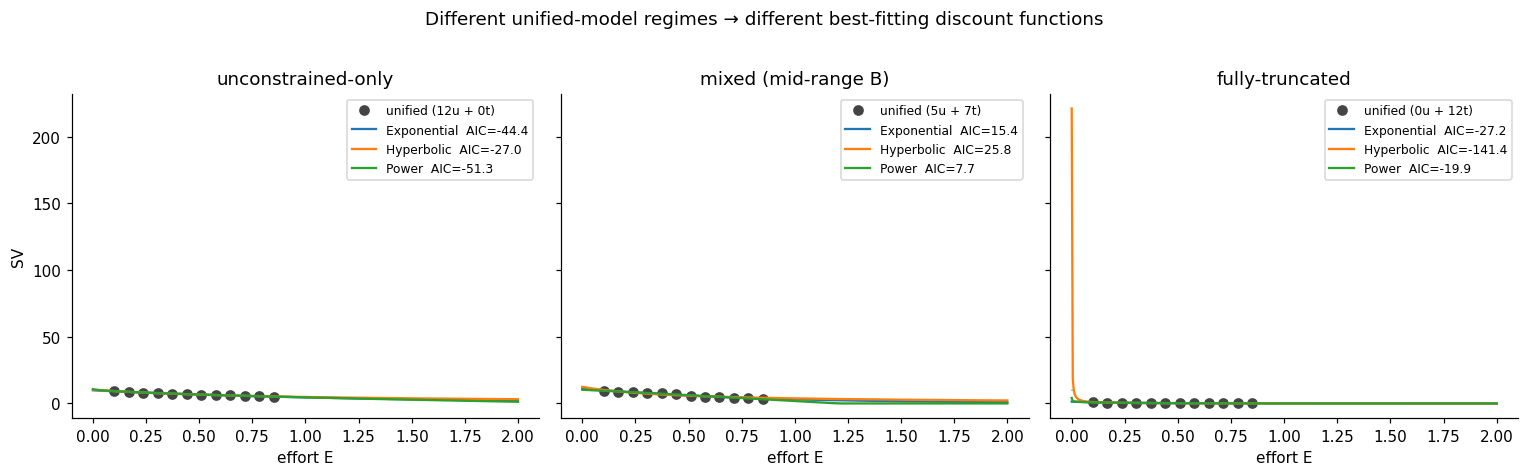

In [5]:
regimes = [
    ("unconstrained-only", {"A": 10.0, "Q0": 5.0, "alpha": 0.5, "k": 1.5, "B": 100.0}),
    ("mixed (mid-range B)", {"A": 10.0, "Q0": 5.0, "alpha": 0.3, "k": 2.0, "B": 1.5}),
    ("fully-truncated", {"A": 10.0, "Q0": 5.0, "alpha": 0.05, "k": 3.0, "B": 0.05}),
]
candidates = [Exponential(), Hyperbolic(), Power()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, (label, p) in zip(axes, regimes):
    E = np.linspace(0.10, 0.85, 12)
    sv = bounded.value(p, E)
    out = bounded.value_with_regime(p, E)
    n_unc = int((out.regime == 0).sum())
    n_trunc = int((out.regime == 1).sum())

    ax.plot(E, sv, "o", color="#444", label=f"unified ({n_unc}u + {n_trunc}t)")
    ax.plot(E_DENSE, bounded.value(p, E_DENSE), color="#444", lw=0.8, alpha=0.5)

    best_aic = np.inf
    for cand in candidates:
        fit = fit_discount(cand, E, sv)
        ax.plot(E_DENSE, cand.value(fit.params, E_DENSE), lw=1.5,
                label=f"{type(cand).__name__}  AIC={fit.aic:.1f}")
        best_aic = min(best_aic, fit.aic)
    ax.set_title(label)
    ax.set_xlabel("effort E"); ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("SV")
fig.suptitle("Different unified-model regimes → different best-fitting discount functions", y=1.02)
fig.tight_layout(); plt.show()

## Step 5, Option A — nonlinear cost (for comparison)

$$ SV(E)/A = 10^{k(\exp(-\alpha Q_0 E^s / A) - 1)} $$

Replace $E$ with $E^s$ (subjective effort = nonlinear function of objective effort). At $s = 1$ this reduces to the naive form. With $s > 1$, the SV curve becomes concave (parabolic-like). 

Option A has *no capability parameter $B$* — it cannot link to measured MVC or N-back capability, so it loses one of the empirical anchors that makes Option B testable. We implement it for cross-form model comparison only.

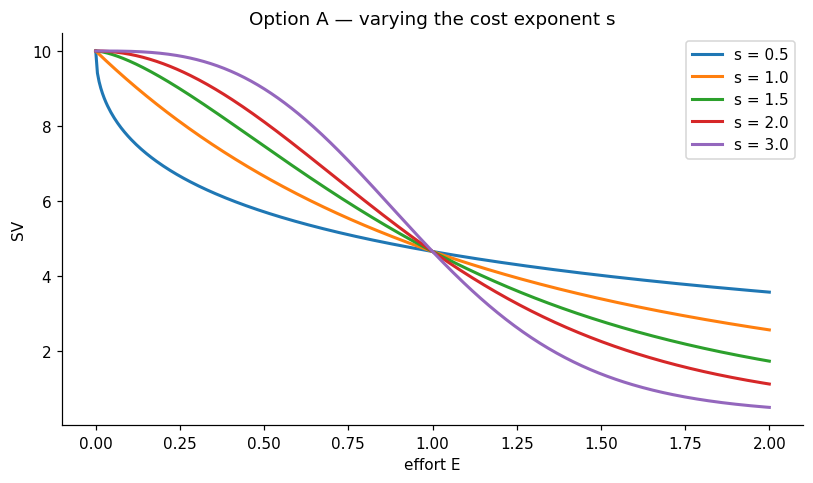

In [6]:
nonlinear = UnifiedNonlinearCost()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for s in [0.5, 1.0, 1.5, 2.0, 3.0]:
    p = {"A": 10.0, "Q0": 5.0, "alpha": 0.5, "k": 1.5, "s": s}
    ax.plot(E_DENSE, nonlinear.value(p, E_DENSE), lw=2, label=f"s = {s}")
ax.set_xlabel("effort E"); ax.set_ylabel("SV")
ax.set_title("Option A — varying the cost exponent s")
ax.legend(loc="upper right")
fig.tight_layout(); plt.show()

## Step 6 — Substitutability via IF

$$ SV_\text{effective}(E) = SV(E) \cdot (1 - IF \cdot Q_{1,\text{consumed}}) $$

When the effortless commodity (1) is consumed, it reduces effective demand for the effortful commodity (2) in proportion to substitutability. $IF=0$ is independence; $IF=1$ is perfect substitutes. The Phase 4 experiment manipulates $IF$ between subjects to test the substitutability prediction (CLAUDE.md §5 H3).

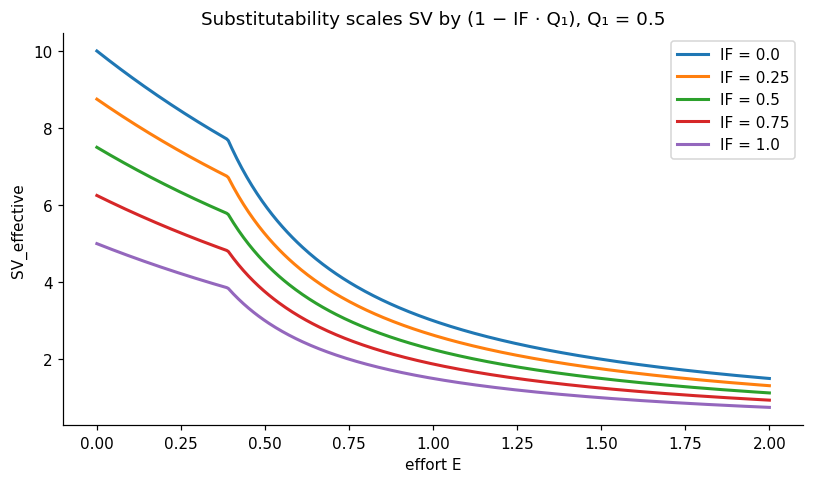

In [7]:
params_b = {"A": 10.0, "Q0": 5.0, "alpha": 0.3, "k": 2.0, "B": 1.5}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for IF in [0.0, 0.25, 0.5, 0.75, 1.0]:
    sv_eff = with_substitutability(
        bounded, params_b, E_DENSE,
        interaction_factor=IF, q1_consumed=0.5,  # half of the substitute available
    )
    ax.plot(E_DENSE, sv_eff, lw=2, label=f"IF = {IF}")
ax.set_xlabel("effort E"); ax.set_ylabel("SV_effective")
ax.set_title("Substitutability scales SV by (1 − IF · Q₁), Q₁ = 0.5")
ax.legend(loc="upper right")
fig.tight_layout(); plt.show()

## Summary

Six things the unified model now buys us, all visible above:

1. **A single-parameter unification** of demand and discounting via $P_\text{effort} = E/A$ (Step 4).
2. **A measurable capability anchor** — $B$ is calibrated from MVC / N-back, not estimated freely (Step 5 Option B).
3. **Both regimes simultaneously** — the experimental sampling crosses the regime boundary, exposing the model in a way single-form discount functions can't (limiting-cases panel).
4. **An adjudication between Option A and Option B** — only Option B has a parameter that should correlate with measured capability; Phase 6 tests this directly.
5. **Substitutability as a pre-registered manipulation** — the $IF$ wrapper turns Hursh's interaction factor into a between-subjects arm.
6. **Falsifiability** — H1 (parameter linkage) can fail; if it does, the unification is empirically wrong and we report it. CLAUDE.md §5 stopping rule.

Phase 3 (next) tests **identifiability and recovery at scale** — we cannot run the experiment until we know the model is empirically distinguishable from its alternatives at the planned sample sizes.